In [2]:
import json
from openai import OpenAI
from tqdm import tqdm
from datasets import load_dataset

/srv/nlprx-lab/share6/gramesh31/LLM-ambiguity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import os
from pathlib import Path
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import csv


In [ ]:
from huggingface_hub import login
login(token="")

In [44]:
random.seed(42)
# load original problems
ds = load_dataset('newfacade/LeetCodeDataset', trust_remote_code=True)
hard_problems = [example for example in ds['train'] if example['difficulty'] == 'Hard']
print(f'Number of hard problems: {len(hard_problems)}')
problems = [(p['question_id'], p['problem_description'].split('\n\xa0')[0].replace('\xa0', " ")) for p in hard_problems 
            if len(p['problem_description'].split('\n\xa0')[0].split('.')) >= 5]
print(f'Number of hard problems with at least 5 sentences: {len(problems)}')

# load ambiguous parts
dir_path = "leetcode/unclear_portion"
unclear_sentences = {}

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n] = list(data.items())

dataset = []
for category in ['algebra', 'counting_and_probability', 'number_theory', 'geometry', 'intermediate_algebra', 'precalculus']:
    ds = load_dataset("EleutherAI/hendrycks_math", category)
    for item in ds['train']:
        dataset.append(item['problem'])
    for item in ds['test']:
        dataset.append(item['problem'])
print(f"Total problems in dataset: {len(dataset)}")
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4 and ('\n' not in p):
        filtered.append(p)

problems += [(i+10000, p) for i, p in enumerate(filtered)]

print(f"Number of filtered problems: {len(problems)}")

# load ambiguous parts
dir_path = "math"

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n+10000] = list(data.items())

from collections import deque
dataset = []
cur_stems = deque([""]*5)
ds = load_dataset("PromptTensor/prompttensor-promptbank")
for item in tqdm(ds['train']):
    if item['intent'] in ['planning', 'generation']:
        if item['prompt_text'][:15] not in cur_stems:
            dataset.append(item['prompt_text'])
            cur_stems.append(item['prompt_text'][:15])
            cur_stems.popleft()
filtered = []
for p in dataset:
    if len(p.split('. ')) >= 4:
        filtered.append(p)

problems += [(i+20000, p) for i, p in enumerate(filtered)]

# load ambiguous parts
dir_path = "writing"

for file in tqdm(Path(dir_path).glob("*.txt")):
    n = int(file.stem)  # "12.txt" -> 12

    with file.open("r", encoding="utf-8") as f:
        try:
            data = json.load(f)  # loads dict from file
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {file}")
            continue

    # convert inner dict to list of (key, value) tuples
    unclear_sentences[n+20000] = list(data.items())

for pid, pdesc in problems:
    unclear_sentences[pid] = [
        (og, new)
        for og, new in unclear_sentences[pid]
        if og in pdesc
    ]
print(f"Number of problems: {len(problems)}")

# check if any unclear sentences were not found in the original problem description
to_delete = []
for pid, sentences in unclear_sentences.items():
    if len(sentences) == 0:
        to_delete.append(pid)
for pid in to_delete:
    del unclear_sentences[pid]

# create dataset with clear+ambiguous sets
clear = [pdesc for _, pdesc in problems]
ambiguous = []
for pid, pdesc in problems:
    if pid not in unclear_sentences:
        continue
    idx = random.randint(0, len(unclear_sentences[pid]) - 1)
    clr, unclr = unclear_sentences[pid][idx]
    ambiguous.append(pdesc.replace(clr, unclr))

questions = clear + ambiguous
labels = [0] * len(clear) + [1] * len(ambiguous)
print(f"Combined dataset prepared with {len(questions)} total questions.")

# filter so that clear and ambiguous prompts from same sample do not both get included
clear = [pdesc for _, pdesc in problems]
ambiguous = []
questions = []
labels = []
for pid, pdesc in problems:
    choice = random.choice([0, 1])
    if pid not in unclear_sentences or choice == 0:
        questions.append(pdesc)
        labels.append(0)
    else:
        clr, unclr = unclear_sentences[pid][0]
        questions.append(pdesc.replace(clr, unclr))
        labels.append(1)
print(f"Final dataset prepared with {len(questions)} total questions.")
print(f"Number of ambiguous questions: {sum(labels)}")
print(f"Number of clear questions: {len(questions) - sum(labels)}")



Number of hard problems: 606
Number of hard problems with at least 5 sentences: 501


501it [00:00, 3376.05it/s]


Total problems in dataset: 10424
Number of filtered problems: 858


357it [00:00, 3481.44it/s]
100%|████████████████████████████████████| 7040/7040 [00:00<00:00, 20946.20it/s]
385it [00:00, 3542.88it/s]

Number of problems: 1243
Combined dataset prepared with 2465 total questions.
Final dataset prepared with 1243 total questions.
Number of ambiguous questions: 643
Number of clear questions: 600


In [6]:
len(questions)

1243

In [301]:
random_state = 1     # 10 writing, 0 coding, 42 math
y = np.array(labels)

# get test sample indices
idxs = np.arange(len(labels))

train_idxs, test_idxs, _, _ = train_test_split(
    idxs, y, test_size=0.25, stratify=y, random_state=random_state
)

In [ ]:
client = OpenAI(api_key="")

In [8]:
USER_TEMPLATE = """You are given a prompt below. Your task is to identify which part of the prompt, if any, is ambiguous.
#####

Output Instructions:
- You must output **only** the sentence that you have identified as ambiguous, or the word "NONE" if there is no ambiguous sentence.
- If a sentence is chosen, it must be copied verbatim from the prompt.
- Do not include explanations, bullet points, or other formatting.

Here is the prompt to analyze:
"{prompt}"

"""

In [9]:
SYSTEM_PROMPT = ""

In [13]:
def evaluate_examples(prompt_text):
    response = client.chat.completions.create(
            model="gpt-5.4-mini",
            messages=[
                {"role": "system", "content": ""},
                {"role": "user", "content": USER_TEMPLATE.format(prompt=prompt_text)},
            ],
            temperature=0.7,
            max_completion_tokens=500,
        )
    content = response.choices[0].message.content.strip()
    return content

In [17]:
len(problems)

1243

In [15]:
i = 0
out = evaluate_examples(questions[0])


In [106]:
clear_prompts = []
unclear_prompts = []
for i, idx in tqdm(enumerate(test_idxs.tolist()), total=len(test_idxs)):
    pid, pdesc = problems[idx]
    if pid not in unclear_sentences:
        continue
    clr, unclr = unclear_sentences[pid][0]
    clear_prompts.append((pid, pdesc))
    unclear_prompts.append((pid, pdesc.replace(clr, unclr)))

100%|█████████████████████████████████████| 311/311 [00:00<00:00, 219971.09it/s]


In [36]:
for i, (id,prompt) in enumerate(tqdm(clear_prompts)):
    response = evaluate_examples(prompt)

    with open(f'gpt_attributions/clear/{id}.txt', 'w', encoding='utf-8') as f:
        f.write(response)

100%|██████████| 305/305 [03:56<00:00,  1.29it/s]


In [ ]:
for i, (id,prompt) in enumerate(tqdm(unclear_prompts)):
    response = evaluate_examples(prompt)

    with open(f'gpt_attributions/unclear/{id}.txt', 'w', encoding='utf-8') as f:
        f.write(response)

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [02:50<00:00,  1.17it/s]


In [46]:
with open(f'gpt_attributions/clear/{20089}.txt', 'r') as f:
    content = f.read().strip()

In [107]:
correct = 0
incorrect = 0
for (id,prompt) in tqdm(clear_prompts):
    # check if file exists    
    with open(f'gpt_attributions/clear/{id}.txt', 'r') as f:
        content = f.read().strip()
    
    if content == "NONE":
        correct += 1
    else:
        incorrect += 1

print(correct, incorrect, correct+incorrect)

100%|████████████████████████████████████████| 305/305 [00:00<00:00, 311.62it/s]

138 167 305


In [304]:
failed_ids = []

for (id,prompt) in tqdm(clear_prompts):
    # check if file exists
    try:
        with open(f'gpt_attributions/clear/{id}.txt', 'r') as f:
            content = f.read().strip()
    except:
        failed_ids.append(id)
        continue
    # read the output file    
    with open(f'gpt_attributions/clear/{id}.txt', 'r') as f:
        content = f.read().strip()

    # check that the key is a contiguous portion of the original prompt
    if content not in prompt and content != "NONE":
        print(f"Response for problem {id} is not a contiguous portion of the original prompt.")
        failed_ids.append(id)
        continue
    # check that the key is only 1 sentence    
    if len(content.split('. ')) >= 2:
        print(f"Response for problem {id} is not only one sentence.")
        failed_ids.append(id)
        continue

print(len(failed_ids))

100%|██████████| 305/305 [00:00<00:00, 7185.05it/s]

Response for problem 1250 is not a contiguous portion of the original prompt.
Response for problem 2977 is not only one sentence.
Response for problem 20199 is not a contiguous portion of the original prompt.
Response for problem 458 is not a contiguous portion of the original prompt.
Response for problem 20029 is not a contiguous portion of the original prompt.
Response for problem 20218 is not a contiguous portion of the original prompt.
Response for problem 2203 is not a contiguous portion of the original prompt.
Response for problem 60 is not a contiguous portion of the original prompt.
Response for problem 3161 is not only one sentence.
Response for problem 20072 is not a contiguous portion of the original prompt.
10


In [307]:
failed_ids = []
correct, incorrect = 0,0
for (id,prompt) in tqdm(unclear_prompts):
    # check if file exists
    try:
        with open(f'gpt_attributions/unclear/{id}.txt', 'r') as f:
            content = f.read().strip()
    except:
        failed_ids.append(id)
        continue
    # read the output file    
    with open(f'gpt_attributions/unclear/{id}.txt', 'r') as f:
        content = f.read().strip()

    # check that the key is a contiguous portion of the original prompt
    if content not in prompt and content != "NONE":
        # print("=="*10)
        # print(f"Response for problem {id} is not a contiguous portion of the original prompt.")
        # print(content)
        # print(prompt)
        failed_ids.append(id)
        continue
    # check that the key is only 1 sentence    
    if len(content.split('. ')) >= 2:
        # print(f"Response for problem {id} is not only one sentence.")
        failed_ids.append(id)
        continue

    # check for correctness
    _, unclr = unclear_sentences[id][0]
    if unclr.strip() in content.strip() or content.strip() in unclr.strip():
        correct += 1
    else:
        incorrect += 1

print(len(failed_ids))
print(correct, incorrect, correct+incorrect)

100%|██████████| 305/305 [00:00<00:00, 7780.88it/s]

5
194 106 300


In [309]:
194/300

0.6466666666666666

In [77]:
failed_ids = set(failed_ids)
for i, (id,prompt) in enumerate(tqdm(unclear_prompts)):
    if id in failed_ids:
        response = evaluate_examples(prompt)

        with open(f'gpt_attributions/unclear/{id}.txt', 'w', encoding='utf-8') as f:
            f.write(response)

100%|██████████| 305/305 [00:03<00:00, 86.85it/s]


In [95]:
def f1(TP, FP, FN):
    if (2*TP + FP + FN) == 0:
        return 0.0
    return (2 * TP) / (2 * TP + FP + FN)

def precision(TP, FP, FN):
    if (TP + FP) == 0:
        return 0.0
    return TP / (TP + FP)

def recall(TP, FP, FN):
    if (TP + FN) == 0:
        return 0.0
    return TP / (TP + FN)

In [98]:
print(f"f1:{f1(194, 167, 106)}")
print(f"precision:{precision(194, 167, 106)}")
print(f"recall:{recall(194, 167, 106)}")

f1:0.5869894099848714
precision:0.5373961218836565
recall:0.6466666666666666


# thresholding

In [14]:
unclear_prompts[0]

(20089,
 'Create a competitive outline for a business coffee seller using a market-force chart. Define three distinct positioning options with supporting value chain activities: Option 1 (premium single-origin traceability), Option 2 (sustainable logistics efficiency), Option 3 (custom blending innovation). For each option, specify: target customer segment, pricing strategy, key partnerships, operational requirements, and defensibility against substitutes. Include risk assessment for each option and recommendation with justification based on market gaps. Address scalability constraints and resource requirements for implementation.')

In [31]:
pdesc

"You are given an integer array nums\u200b\u200b\u200b and an integer k. You are asked to distribute this array into k subsets of equal size such that there are no two equal elements in the same subset.\nA subset's incompatibility is the difference between the maximum and minimum elements in that array.\nProvide the least potential aggregation of disharmony values of the k clusters upon arranging the collection ideally, or give back -1 if it cannot be achieved.\nA subset is a group integers that appear in the array with no particular order."

In [46]:
with open(f"combined_attributions/combined/prig/prig_12_14_attribution_results.json", "r") as f:
    results = json.load(f)
unclear_pids = {}

for k in results:
    unclear_pids[results[k]['pid']] = (results[k]['attributions'], results[k]['mask'], results[k]['tokens'])

with open(f"combined_attributions/combined/prig/prig_12_14_attribution_results.json", "r") as f:
    results = json.load(f)

errs = 0
unclear_filtered = {}
for (pid, pdesc) in problems:
    if pid in unclear_pids: #results[pid]['pdesc'] != pdesc:
        unclear_filtered[pid] = pdesc

len(unclear_filtered)
    

305

In [47]:
with open(f"combined_attributions_clear/combined/prig/prig_13_15_attribution_results.json", "r") as f:
    results = json.load(f)
clear_pids = {}

for k in results:
    clear_pids[results[k]['pid']] = (results[k]['attributions'], results[k]['mask'], results[k]['tokens'])


with open(f"combined_attributions_clear/combined/prig/prig_13_15_attribution_results.json", "r") as f:
    results = json.load(f)

errs = 0
clear_filtered = {}
for (pid, pdesc) in problems:
    if pid in clear_pids: #results[pid]['pdesc'] != pdesc:
        clear_filtered[pid] = pdesc

len(clear_filtered)


    

305

In [51]:
thresholds = np.linspace(0, 1, 100)

In [454]:
unclear_res = []
tps = []
fns = []
for t in tqdm(thresholds):
    correct = 0
    for pid, pdesc in unclear_filtered.items():
        clr,unclr = unclear_sentences[pid][0]
        attribution, mask, tokens = unclear_pids[pid]
        attribution, mask = np.array(attribution), np.array(mask)

        # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
        attribution = (attribution) / (attribution.max())
        
        attribution = gaussian_smooth(attribution, sigma=3)

        sentence_avgs = []
        cur = []
        for i,tkn in enumerate(tokens):
            cur.append(float(attribution[i]))
            if ((len(cur) > 5) and (('.' in tkn) or ('?' in tkn))) and ('.length' not in tkn):
                sentence_avgs.append(sum(cur)/len(cur))
                cur = []
        
        num_sents_greater = 0
        for avg in sentence_avgs:
            if avg > float((attribution[mask==1]).mean()):
                num_sents_greater += 1

        if (float((attribution[mask==1]).mean()) > t) and num_sents_greater <= 1:
            correct += 1

        # print((attribution[mask==1]))
        # print(float((attribution[mask==1]).mean()))
        # print(num_sents_greater, len(sentence_avgs))

        # if float((attribution[mask==1]).mean()) > t:
        #     correct += 1

    unclear_res.append(correct / len(unclear_filtered))
    tps.append(correct)
    fns.append(len(unclear_filtered) - correct)

100%|██████████| 150/150 [00:12<00:00, 11.61it/s]


In [455]:
clear_res = []
tns = []
fps = []
for t in tqdm(thresholds):
    correct = 0
    for pid, pdesc in clear_filtered.items():
        clr,unclr = unclear_sentences[pid][0]
        attribution, mask, tokens = clear_pids[pid]
        attribution, mask = np.array(attribution), np.array(mask)

        # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
        attribution = (attribution) / (attribution.max())
        
        attribution = gaussian_smooth(attribution, sigma=3)

        sentence_avgs = []
        cur = []
        for i,tkn in enumerate(tokens):
            cur.append(float(attribution[i]))
            if ((len(cur) > 5) and (('.' in tkn) or ('?' in tkn))) and ('.length' not in tkn):
                sentence_avgs.append(sum(cur)/len(cur))
                cur = []
        
        num_sents_greater = 0
        for avg in sentence_avgs:
            if avg > float((attribution[mask==1]).mean()):
                num_sents_greater += 1

        # if (float((attribution[mask==1]).mean()) > t):
        #     correct += 1
        if max(sentence_avgs) > t:
            correct += 1

        # if float((attribution[mask==1]).mean()) > t:
        #     correct += 1

    clear_res.append(correct / len(clear_filtered))
    tns.append(len(clear_filtered) - correct)
    fps.append(correct)

100%|██████████| 150/150 [00:12<00:00, 11.58it/s]


In [86]:
def get_metrics_clear(split, thresholds):
    clear_res = []
    tns = []
    fps = []
    for t in tqdm(thresholds):
        correct = 0
        for pid, pdesc in split:
            clr,unclr = unclear_sentences[pid][0]
            attribution, mask, tokens = clear_pids[pid]
            attribution, mask = np.array(attribution), np.array(mask)

            # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
            attribution = (attribution) / (attribution.max())
            
            attribution = gaussian_smooth(attribution, sigma=3)

            sentence_avgs = []
            cur = []
            for i,tkn in enumerate(tokens):
                cur.append(float(attribution[i]))
                if ((len(cur) > 5) and (('.' in tkn) or ('?' in tkn))) and ('.length' not in tkn):
                    sentence_avgs.append(sum(cur)/len(cur))
                    cur = []
            
            num_sents_greater = 0
            for avg in sentence_avgs:
                if avg > float((attribution[mask==1]).mean()):
                    num_sents_greater += 1

            # if (float((attribution[mask==1]).mean()) > t):
            #     correct += 1
            if max(sentence_avgs) > t:
                correct += 1

            # if float((attribution[mask==1]).mean()) > t:
            #     correct += 1

        clear_res.append(correct / len(split))
        tns.append(len(split) - correct)
        fps.append(correct)
    return tns, fps

In [85]:
def get_metrics_unclear(split, thresholds):
    unclear_res = []
    tps = []
    fns = []
    for t in tqdm(thresholds):
        correct = 0
        for pid, pdesc in split:
            clr,unclr = unclear_sentences[pid][0]
            attribution, mask, tokens = unclear_pids[pid]
            attribution, mask = np.array(attribution), np.array(mask)

            # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
            attribution = (attribution) / (attribution.max())
            
            attribution = gaussian_smooth(attribution, sigma=3)

            sentence_avgs = []
            cur = []
            for i,tkn in enumerate(tokens):
                cur.append(float(attribution[i]))
                if ((len(cur) > 5) and (('.' in tkn) or ('?' in tkn))) and ('.length' not in tkn):
                    sentence_avgs.append(sum(cur)/len(cur))
                    cur = []
            
            num_sents_greater = 0
            for avg in sentence_avgs:
                if avg > float((attribution[mask==1]).mean()):
                    num_sents_greater += 1

            if (float((attribution[mask==1]).mean()) > t) and num_sents_greater <= 1:
                correct += 1

            # print((attribution[mask==1]))
            # print(float((attribution[mask==1]).mean()))
            # print(num_sents_greater, len(sentence_avgs))

            # if float((attribution[mask==1]).mean()) > t:
            #     correct += 1

        unclear_res.append(correct / len(split))
        tps.append(correct)
        fns.append(len(split) - correct)
    return tps, fns

In [72]:
f1s

[0.19484240687679083]

In [109]:
fold_f1s = []
fold_precs = []
fold_recalls = []
thresholds = np.linspace(0, 1, 100)
unclr = list(unclear_filtered.items())
clr = list(clear_filtered.items())
folds = 5
for i in range(folds):
    split_idxs = set([j for j in range(i, len(clr), folds)])
    clr_train = [item for idx, item in enumerate(clr) if idx not in split_idxs]
    unclr_train = [item for idx, item in enumerate(unclr) if idx not in split_idxs]
    clr_test = [item for idx, item in enumerate(clr) if idx in split_idxs]
    unclr_test = [item for idx, item in enumerate(unclr) if idx in split_idxs]

    tns, fps = get_metrics_clear(clr_train, thresholds)
    tps, fns = get_metrics_unclear(unclr_train, thresholds)
    f1s = [f1(tp, fp, fn) for tp, fp, fn in zip(tps, fps, fns)]
    print(max(f1s))
    t = thresholds[int(np.argmax(f1s))]
    print(t)
    tns, fps = get_metrics_clear(clr_test, [t])
    tps, fns = get_metrics_unclear(unclr_test, [t])
    f1s = [f1(tp, fp, fn) for tp, fp, fn in zip(tps, fps, fns)]
    precs = [precision(tp, fp, fn) for tp, fp, fn in zip(tps, fps, fns)]
    recs = [recall(tp, fp, fn) for tp, fp, fn in zip(tps, fps, fns)]
    print(max(f1s))
    fold_f1s.append(max(f1s))
    fold_precs.append(max(precs))
    fold_recalls.append(max(recs))
    


100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 51.52it/s]


0.7384615384615385
0.10101010101010102


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 188.27it/s]


0.7586206896551724


100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 51.03it/s]


...

0.7433628318584071


100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 51.38it/s]


0.7668845315904139
0.11111111111111112


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 177.86it/s]

0.6476190476190476


In [100]:
fold_f1s = np.array(fold_f1s)
fold_f1s.mean(), fold_f1s.std()

(np.float64(0.7342253832690095), np.float64(0.044116024348570225))

In [110]:
fold_f1s = np.array(fold_f1s)
fold_precs = np.array(fold_precs)
fold_recalls = np.array(fold_recalls)
print(f"f1:{float(fold_f1s.mean()), float(fold_f1s.std())}")
print(f"precision:{float(fold_precs.mean()), float(fold_precs.std())}")
print(f"recall:{float(fold_recalls.mean()), float(fold_recalls.std())}")

f1:(0.7342253832690095, 0.044116024348570225)
precision:(0.8076315351315351, 0.026300397289870034)
recall:(0.6754098360655737, 0.06340681837971714)


In [63]:
f1s = [f1(tp, fp, fn) for tp, fp, fn in zip(tps, fps, fns)]

NameError: name 'tps' is not defined

In [62]:
thresholds[np.argmax(f1s)]

NameError: name 'f1s' is not defined

In [458]:
max(f1s)

0.7450980392156863

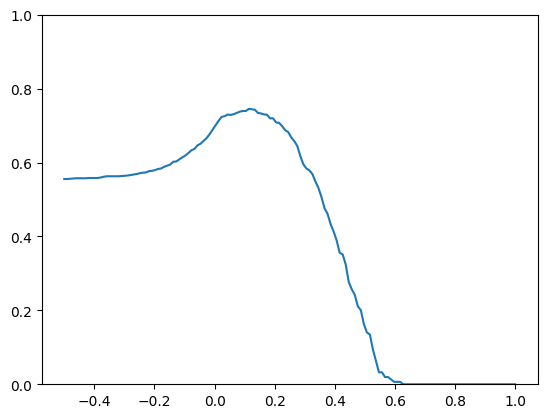

In [459]:
plt.plot(thresholds, f1s, label="f1")
plt.ylim(0, 1)



plt.show()

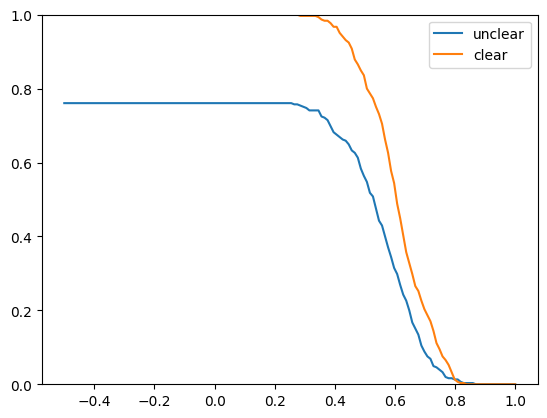

In [445]:
plt.plot(thresholds, unclear_res, label="unclear")
plt.plot(thresholds, clear_res, label="clear")
plt.legend()
plt.ylim(0, 1)



plt.show()

In [70]:
# smooth attribution scores with a Gaussian kernel
from scipy.ndimage import gaussian_filter1d
def gaussian_smooth(attribution, sigma=3):
    if sigma == 0:
        return np.array(attribution)
    attribution = np.array(attribution)
    return gaussian_filter1d(attribution, sigma=sigma)

In [124]:
def split_sentences(tokens):
    res = []
    cur = []
    for t in tokens:
        cur.append(t)
        if '.' in t:
            res.append(cur)
            cur = []            
    if len(cur) > 0:
        res.append(cur)
    return res

In [238]:
correct = 0
for pid, pdesc in clear_filtered.items():
    clr,unclr = unclear_sentences[pid][0]
    attribution, mask, tokens = clear_pids[pid]
    attribution, mask = np.array(attribution), np.array(mask)
    # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
    attribution = (attribution) / (attribution.max())
    # attribution = gaussian_smooth(attribution, sigma=3)
    
    sentence_avgs = []
    cur = []
    for i,t in enumerate(tokens):
        cur.append(float(attribution[i]))
        if '.' in t:
            sentence_avgs.append(round(sum(cur)/len(cur), 2))
            cur = []
    # print(round(float((attribution * mask).mean()), 2))
    print(round(float((attribution[mask==1]).mean()), 2), sorted(sentence_avgs, reverse=True))
    if round(float((attribution[mask==1]).mean()), 2) >= sorted(sentence_avgs, reverse=True)[0]:
        correct += 1

correct / len(filtered)

-0.32 [0.1, -0.14]
-4.61 [-0.39, -0.4, -0.45, -0.48, -0.57, -0.62, -0.68, -0.73, -0.75, -0.76, -0.82, -1.03, -1.03, -1.13, -1.17, -1.17, -1.18, -1.28, -4.72]
-1.39 [0.05, -0.27, -0.42]
-0.26 [0.01, -0.14, -0.19, -0.23, -0.31, -0.5]
-0.34 [0.01, -0.09, -0.09, -0.14, -0.19, -0.3, -0.4, -0.58, -0.68]
-0.66 [-0.28, -0.52, -0.68, -0.72, -2.28]
-0.27 [-0.16, -0.17, -0.17, -0.18, -0.18, -0.22, -0.27, -0.33, -0.49, -0.51, -0.55]
-0.16 [0.21, -0.08, -0.09, -0.11, -0.12, -0.14, -0.14, -0.19, -0.2, -0.2]
-0.15 [0.11, -0.01, -0.03, -0.05, -0.06, -0.06, -0.07, -0.12]
0.06 [0.16, 0.02, -0.05, -0.14, -0.22, -0.23]
-0.31 [-0.22, -0.31, -0.33, -0.35, -0.55, -0.77, -0.89]
-0.32 [0.04, -0.32, -0.45]
-0.72 [0.06, -0.15, -0.47]
-0.43 [-0.34, -0.39, -0.4, -0.88, -1.2]
-0.25 [0.01, -0.03, -0.05, -0.1, -0.2, -0.21]
-0.85 [-0.14, -0.2, -0.41, -0.95]
-0.2 [0.01, -0.01, -0.02, -0.02, -0.05, -0.1, -0.13, -0.2, -0.25, -0.26]
-0.11 [-0.12, -0.12, -0.14, -0.15, -0.2, -0.27, -0.29, -0.29, -0.34]
-0.23 [0.01, -0.11, -

0.21639344262295082

0.5606557377049181

In [ ]:
for pid, pdesc in filtered.items():
    clr,unclr = unclear_sentences[pid][0]
    attribution, mask, tokens = pids[pid]
    attribution, mask = np.array(attribution), np.array(mask)
    # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
    attribution = (attribution) / (attribution.max())
    # attribution = softmax(attribution)
    attribution = gaussian_smooth(attribution, sigma=3)
    print(round(float((attribution * mask).mean()), 2))
    

0.05
0.16
0.06
0.03
0.01
0.13
0.0
0.02
0.01
0.02
0.0
0.01
0.03
0.02
0.05
0.03
0.05
0.01
0.07
0.01
0.18
0.07
0.06
0.01
0.01
0.11
0.04
0.05
0.01
0.03
0.1
0.06
0.1
0.09
0.01
0.03
0.03
0.09
0.01
0.13
0.01
0.05
0.04
0.04
0.05
0.01
0.04
0.04
0.01
0.08
0.03
0.02
0.02
0.01
0.08
0.01
0.0
0.01
0.03
0.0
0.04
0.1
0.03
0.08
0.03
0.01
0.03
0.01
0.03
0.18
0.08
0.06
0.01
0.02
0.01
0.05
0.03
0.04
0.05
0.03
0.11
0.01
0.04
0.03
0.05
0.02
0.03
0.01
0.02
0.03
0.1
0.04
0.06
0.01
0.01
0.03
0.08
0.02
0.05
0.01
0.09
0.02
0.03
0.01
0.03
0.02
0.07
0.03
0.01
-0.0
0.1
0.1
0.1
0.12
0.12
0.12
0.05
0.11
0.06
0.04
0.16
0.07
0.08
0.07
0.03
0.07
0.07
0.04
0.07
0.15
0.02
0.07
0.1
0.25
0.06
0.08
0.01
-0.02
0.02
0.06
0.06
0.07
0.11
0.04
0.17
0.09
0.22
0.07
0.04
0.04
0.03
0.02
0.07
0.13
0.06
0.01
0.07
0.11
0.16
0.06
0.11
0.01
0.03
0.05
0.03
0.06
0.15
0.17
0.03
0.11
0.05
0.26
0.03
0.05
0.05
0.1
-0.01
0.11
0.05
0.13
0.1
0.05
0.02
0.07
0.05
0.15
0.01
0.08
0.11
0.05
0.03
0.02
0.04
0.15
0.04
0.04
0.1
0.05
0.03
0.09
0.05
0.1
0.07

In [84]:
attribution.max()

np.float64(0.6772371099694681)

In [76]:
attribution

array([ 0.01407603,  0.0258513 ,  0.0446512 ,  0.06351352,  0.07669031,
        0.08186212,  0.08016701,  0.07455913,  0.06791821,  0.06203999,
        0.05773837,  0.05545478,  0.05563878,  0.05861599,  0.06413713,
        0.07113699,  0.07803347,  0.08339676,  0.08660694,  0.08800205,
        0.0884762 ,  0.08886938,  0.08955807,  0.09044715,  0.09120236,
        0.09148991,  0.09099618,  0.08935788,  0.08610833,  0.08081078,
        0.07327067,  0.06373019,  0.05292406,  0.04196729,  0.03214078,
        0.02462367,  0.02022483,  0.01917216,  0.02101185,  0.02467879,
        0.02873014,  0.03175848,  0.0328508 ,  0.03185578,  0.02935865,
        0.02632301,  0.0236459 ,  0.02186932,  0.02112928,  0.02123902,
        0.02176283,  0.02208124,  0.02151108,  0.01956602,  0.01621163,
        0.01198073,  0.00780001,  0.00462255,  0.00304931,  0.00312426,
        0.00437679,  0.00605945,  0.00742971,  0.00794899,  0.00735526,
        0.00566829,  0.00315575,  0.0003114 , -0.0022375 , -0.00

In [72]:
(attribution * mask)

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , -0.        , -0.  

In [91]:
round(float((attribution * mask).mean()), 2)

0.15

In [81]:
def plot_heatmap(scores, mask):
    """Plots a 1D heatmap of token attributions.
    Args:
        tokens: List of token strings
        scores: List of attribution scores (same length as tokens)
        title: Title for the plot
        mask: Optional binary mask to highlight certain tokens (e.g., ground-truth ambiguous tokens)
    """
    
    # Normalize scores from 0 to 1 for easier coloring
    scores_norm = scores
    

    fig, ax = plt.subplots(figsize=(15, 2))   # ← define ax

    sns.heatmap(
        [scores_norm],
        yticklabels=False,
        cmap="Reds",
        annot=[[f"{s:.2f}" for s in scores]],
        fmt="",
        cbar=False,
        ax=ax                                  # ← pass ax
    )



    if mask is not None:
        mask = np.asarray(mask).astype(bool)
        for tick, m in zip(ax.get_xticklabels(), mask):
            if m:
                tick.set_color("blue")     # change color here
    # plt.tight_layout()
    plt.show()